In [2]:
import pandas as pd

hur_dat = pd.read_csv('Hurricanes.csv', skiprows=1)
hur_dat = hur_dat.rename(columns={'Unnamed: 0':'Name','Unnamed: 1':'start','Unnamed: 2':'end','Unnamed: 3':'Category'}).dropna(how='all')
hur_dat['start'] = pd.to_datetime(hur_dat['start'])
hur_dat['end'] = pd.to_datetime(hur_dat['end'])
hur_dat

/var/folders/z6/1637m0dd1p1dn2n4wrbvj6kw0000gn/T/ipykernel_91402/4286610772.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hur_dat['start'] = pd.to_datetime(hur_dat['start'])
/var/folders/z6/1637m0dd1p1dn2n4wrbvj6kw0000gn/T/ipykernel_91402/4286610772.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hur_dat['end'] = pd.to_datetime(hur_dat['end'])


,Name,start,end,Category,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Milton,2024-10-09,2024-10-10,2.0,NaN,NaN,NaN,NaN,NaN
1,Helene,2024-09-26,2024-09-28,4.0,NaN,NaN,NaN,NaN,NaN
2,Francine,2024-09-10,2024-09-12,2.0,NaN,NaN,NaN,NaN,NaN
3,Debby,2024-08-04,2024-08-08,1.0,NaN,NaN,NaN,NaN,NaN
4,Beryl,2024-07-08,2024-07-09,1.0,NaN,NaN,NaN,NaN,NaN
5,Idalia,2023-08-30,2023-08-31,3.0,NaN,NaN,NaN,NaN,NaN
6,Nicole,2022-11-09,2022-11-11,1.0,NaN,NaN,NaN,NaN,NaN
7,Ian,2022-09-27,2022-09-30,4.0,NaN,NaN,NaN,NaN,NaN
8,Nicholas,2021-09-13,2021-09-16,1.0,NaN,NaN,NaN,NaN,NaN
9,Ida,2021-08-28,2021-09-01,4.0,NaN,NaN,NaN,NaN,NaN


In [3]:
import datetime as dt
import requests
import zipfile
import os
import time

for i in range(len(hur_dat)):
    storm = hur_dat['Name'][i]
    base_url = "https://services.nacse.org/prism/data/get/us/4km/ppt"

    start = hur_dat['start'][i]
    stop = hur_dat['end'][i]

    current = start
    while current <= stop:
        day = current.strftime("%Y%m%d")
        url = f"{base_url}/{day}?format=nc"

        print(f"Downloading {url}")

        response = requests.get(url, stream=True)
        response.raise_for_status()

        # Temporary ZIP filename
        zip_filename = f"tmp_{day}.zip"
        with open(zip_filename, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        # Extract only the .nc file
        with zipfile.ZipFile(zip_filename, 'r') as z:
            for member in z.namelist():
                if member.endswith(".nc"):
                    # Save extracted nc with storm name
                    outname = f"{storm}_{day}.nc"
                    z.extract(member)
                    os.rename(member, outname)
                    print(f"Saved {outname}")

        # Remove ZIP
        os.remove(zip_filename)

        time.sleep(2)
        current += dt.timedelta(days=1)


Saved Milton_20241009.nc
Saved Milton_20241010.nc
Saved Helene_20240926.nc
Saved Helene_20240927.nc
Saved Helene_20240928.nc
Saved Francine_20240910.nc
Saved Francine_20240911.nc
Saved Francine_20240912.nc
Saved Debby_20240804.nc
Saved Debby_20240805.nc
Saved Debby_20240806.nc
Saved Debby_20240807.nc
Saved Debby_20240808.nc
Saved Beryl_20240708.nc
Saved Beryl_20240709.nc
Saved Idalia_20230830.nc
Saved Idalia_20230831.nc
Saved Nicole_20221109.nc
Saved Nicole_20221110.nc
Saved Nicole_20221111.nc
Saved Ian_20220927.nc
Saved Ian_20220928.nc
Saved Ian_20220929.nc
Saved Ian_20220930.nc
Saved Nicholas_20210913.nc
Saved Nicholas_20210914.nc
Saved Nicholas_20210915.nc
Saved Nicholas_20210916.nc
Saved Ida_20210828.nc
Saved Ida_20210829.nc
Saved Ida_20210830.nc
Saved Ida_20210831.nc
Saved Ida_20210901.nc
Saved Zeta_20201028.nc
Saved Zeta_20201029.nc
Saved Delta_20201009.nc
Saved Delta_20201010.nc
Saved Sally_20200912.nc
Saved Sally_20200913.nc
Saved Sally_20200914.nc
Saved Sally_20200915.nc
Saved

/Users/xochitlhidalgo/miniforge3/envs/coding_env/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/xochitlhidalgo/miniforge3/envs/coding_env/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/xochitlhidalgo/miniforge3/envs/coding_env/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


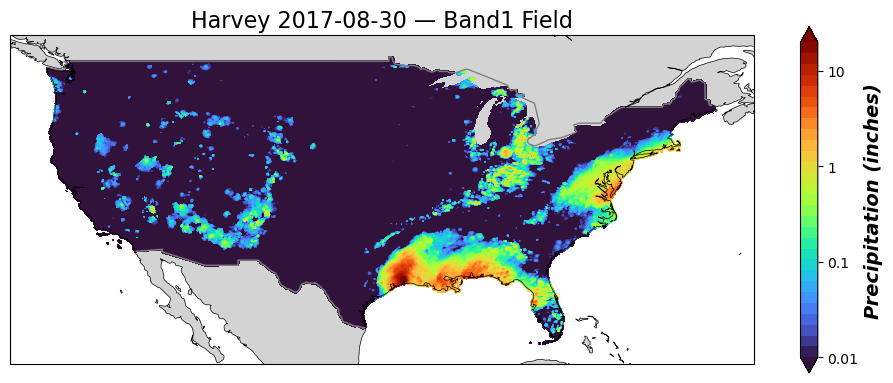

In [16]:
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.dates as mdates
import matplotlib.dates as ticker
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import numpy as np





# Load data
pr = xr.open_dataset('rain_data/Harvey_20170830.nc')



data = pr.Band1.values / 25.4

data[data <= 0] = 0.01

levels = np.logspace(np.log10(0.01), np.log10(20), 30)

# Meshgrid
lon2, lat2 = np.meshgrid(pr.lon, pr.lat)

# Map projection
projection = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

plt.figure(figsize=(12,6))
ax = plt.subplot(111, projection=projection)

# Map features
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines(resolution='50m', color='black', linewidth=0.5)

# Filled contours
cs = ax.contourf(
    lon2, lat2, data,
    levels=levels,
    norm=LogNorm(vmin=0.01, vmax=20),
    cmap='turbo',      # or any colormap you prefer
    extend='both',
    transform=data_crs
)



# Colorbar
cbar = plt.colorbar(cs, shrink=0.75)
cbar.ax.set_ylabel('Precipitation (inches)', weight='bold', size=14, style='italic')

cbar.ax.set_yticks([0.01, 0.1, 1, 10])
cbar.ax.set_yticklabels(['0.01', '0.1', '1', '10'])



plt.title("Harvey 2017-08-30 — Band1 Field", fontsize=16)
plt.show()
